# Cancer Mutation Classification — Oncogenicity-Focused Analysis
This pipeline classifies genetic mutations as **Oncogenic** or **Non-Oncogenic** using a multi-tiered labeling strategy based on ClinVar's Oncogenicity annotations, Somatic Clinical Impact tiers, and cancer-phenotype-matched pathogenicity data.

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

sys.path.append(os.path.abspath('..'))

from src.data_loader import load_clean_data
from src.features import FeatureEngineer
from src.training import train_pipeline
from src.evaluation import evaluate_medical_utility, plot_visual_assessment
from src.config import RANDOM_STATE, TEST_SIZE

from src.gpu_setup import setup_gpu
setup_gpu()
import pickle
from tensorflow.keras.models import load_model

I0000 00:00:1776979787.140849   36060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776979787.199369   36060 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776979789.360551   36060 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


✅ GPU Mode Active: 1 Physical GPUs, 1 Logical GPUs configured.


I0000 00:00:1776979791.204243   36060 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2285 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 1. Data Procurement
Loading variants with multi-tiered cancer-specific labeling:
- **Tier 1 (Gold):** ClinVar Oncogenicity = "Oncogenic" or "Likely oncogenic"
- **Tier 2 (Silver):** Somatic Clinical Impact = Tier I or Tier II
- **Tier 3 (Bronze):** Pathogenic + Cancer phenotype keywords
- **Negative:** ClinSigSimple = 0 (reliably benign)

In [6]:
df = load_clean_data()

train_df, test_df = train_test_split(
    df, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=df['CancerLabel']
)

print(f"Training set: {len(train_df)} variants")
print(f"Test set: {len(test_df)} variants")

Dataset successfully loaded. Final size: 600185 variants.
  Oncogenic (positive): 23296 (3.9%)
  Benign (negative):    576889 (96.1%)
Training set: 510157 variants
Test set: 90028 variants


## 2. Feature Engineering & Preparation
Extracting biological features: Ti/Tv ratio, origin (somatic/germline), allele length, gene-level oncogenic frequency, and categorical embeddings for Gene, Chromosome, Variant Type, and Origin.

In [7]:
engineer = FeatureEngineer()
X_train = engineer.fit_transform(train_df)
X_test = engineer.transform(test_df)

y_train = train_df['CancerLabel'].values
y_test = test_df['CancerLabel'].values

## 3. Neural Architecture & Training
The model uses Focal Loss (alpha=0.75) combined with computed class weights to handle severe class imbalance. Architecture: 256→128→64 dense layers with embedding inputs for categorical features.

In [8]:
model, history = train_pipeline(X_train, y_train, engineer)

# Save the model and feature engineer for future usey
if not os.path.exists('models'):
    os.makedirs('models')
model.save('models/mutation_classifier.h5')
with open('models/feature_engineer.pkl', 'wb') as f:
    pickle.dump(engineer, f)
print("Model and Feature Engineer saved successfully in 'models/' directory.")

Class weights: {np.int64(0): np.float64(0.5201914939176719), np.int64(1): np.float64(12.881451368548632)}
Epoch 1/100


I0000 00:00:1776979396.949436   34268 service.cc:153] XLA service 0x7f0334038440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776979396.949529   34268 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1776979397.052490   34268 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776979397.489305   34268 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1776979397.610704   34268 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3966__.38
I0000 00:00:1776979400.874584   34437 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_28', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776979403.230248   34440 subprocess_compilation.cc:348] pt

 23/847 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8714 - loss: 0.0455 - precision: 0.1240 - recall: 0.3220    

I0000 00:00:1776979407.026931   34268 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_maximum_reduce_fusion', 4 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776979407.055495   34268 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


842/847 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9489 - loss: 0.0180 - precision: 0.4025 - recall: 0.5446

I0000 00:00:1776979410.304982   34265 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3966__.38


847/847 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9490 - loss: 0.0180 - precision: 0.4031 - recall: 0.5451

I0000 00:00:1776979419.162743   34268 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


847/847 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.9612 - loss: 0.0128 - precision: 0.4995 - recall: 0.6270 - val_accuracy: 0.9749 - val_loss: 0.0088 - val_precision: 0.6785 - val_recall: 0.6798 - learning_rate: 0.0010
Epoch 2/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9717 - loss: 0.0091 - precision: 0.6230 - recall: 0.6847 - val_accuracy: 0.9741 - val_loss: 0.0087 - val_precision: 0.6560 - val_recall: 0.7083 - learning_rate: 0.0010
Epoch 3/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9730 - loss: 0.0086 - precision: 0.6394 - recall: 0.6976 - val_accuracy: 0.9747 - val_loss: 0.0088 - val_precision: 0.6656 - val_recall: 0.7086 - learning_rate: 0.0010
Epoch 4/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9735 - loss: 0.0083 - precision: 0.6456 - recall: 0.7008 - val_accuracy: 0.9758 - val_loss: 0.0089 - val_precision: 0.6894 - val_recall: 0.6935 - learning_rate: 0.0010
Epoch 5/100
847/847 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.973

Model and Feature Engineer saved successfully in 'models/' directory.


## 4. Medical Utility Assessment

2814/2814 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step

--- Clinical Performance Appraisal (Threshold: 0.3580) ---
                   precision    recall  f1-score   support

Non-Oncogenic (0)       1.00      0.92      0.96     86534
    Oncogenic (1)       0.31      0.90      0.46      3494

         accuracy                           0.92     90028
        macro avg       0.65      0.91      0.71     90028
     weighted avg       0.97      0.92      0.94     90028



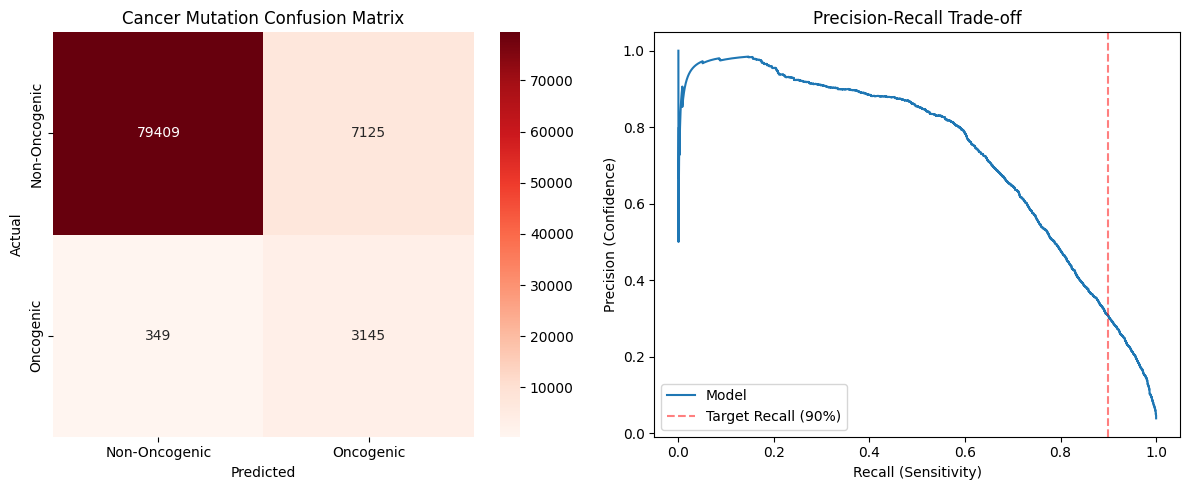

In [9]:
y_pred, y_probs, threshold = evaluate_medical_utility(model, X_test, y_test)
plot_visual_assessment(y_test, y_pred, y_probs)

## 5. Interactive Clinical Inference & Interpretation
This section allows biologists to test the model with individual mutations and receive a human-readable clinical report instead of raw metrics.

In [2]:
from src.evaluation import report_inference

# If running just this cell without training, load the saved model automatically
if 'model' not in locals() or 'engineer' not in locals():
    print("Loading pre-trained model and features from disk...")
    import pickle
    from tensorflow.keras.models import load_model
    from src.model import focal_loss
    model = load_model('models/mutation_classifier.h5', custom_objects={'focal_loss_fixed': focal_loss(gamma=2.0, alpha=0.75)})
    with open('models/feature_engineer.pkl', 'rb') as f:
        engineer = pickle.load(f)
    # Using default threshold from last full training run
    threshold = 0.3619

# --- INTERACTIVE TEST AREA ---
# You can test any variant by modifying this list.

variants_to_test = [
    {
        'GeneID': 3845,
        'GeneSymbol': 'KRAS',
        'PositionVCF': 25245350,
        'ReferenceAlleleVCF': 'C',
        'AlternateAlleleVCF': 'T',
        'Type': 'snp',
        'Chromosome': '12',
        'OriginSimple': 'somatic'
    },
    {
        'GeneID': 7157,
        'GeneSymbol': 'TP53',
        'PositionVCF': 7674220,
        'ReferenceAlleleVCF': 'C',
        'AlternateAlleleVCF': 'T',
        'Type': 'snp',
        'Chromosome': '17',
        'OriginSimple': 'somatic'
    },
    {
        'GeneID': 1956,
        'GeneSymbol': 'EGFR',
        'PositionVCF': 55181378,
        'ReferenceAlleleVCF': 'T',
        'AlternateAlleleVCF': 'G',
        'Type': 'snp',
        'Chromosome': '7',
        'OriginSimple': 'somatic'
    }
]

for v in variants_to_test:
    report_inference(model, engineer, v, threshold)


Loading pre-trained model and features from disk...


I0000 00:00:1776979799.093462   36157 service.cc:153] XLA service 0x7fbd88042340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776979799.093536   36157 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6 (Driver: 12.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1776979799.113295   36157 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776979799.183764   36157 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1776979799.756027   36157 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



      CANCER MUTATION CLINICAL REPORT
VARIANT: KRAS (ID: 3845) | Pos: 25245350
DNA CHANGE: C -> T
ORIGIN: somatic
--------------------------------------------------
FINAL CLASSIFICATION: PATHOGENIC (ONCOGENIC)
CONFIDENCE SCORE: 73.0%
RISK LEVEL: MODERATE
--------------------------------------------------
BIOLOGICAL CONTEXT:
 - Mutation Type: snp (Transition)

CLINICAL ADVICE:
 [!] High priority for clinical follow-up.
 [!] Mutation shows genomic signatures common in cancer drivers.

      CANCER MUTATION CLINICAL REPORT
VARIANT: TP53 (ID: 7157) | Pos: 7674220
DNA CHANGE: C -> T
ORIGIN: somatic
--------------------------------------------------
FINAL CLASSIFICATION: PATHOGENIC (ONCOGENIC)
CONFIDENCE SCORE: 81.4%
RISK LEVEL: HIGH
--------------------------------------------------
BIOLOGICAL CONTEXT:
 - Mutation Type: snp (Transition)

CLINICAL ADVICE:
 [!] High priority for clinical follow-up.
 [!] Mutation shows genomic signatures common in cancer drivers.
 [!!] Very high confidence — 